Author:  
Manuel Eugenio Morocho Cayamcela, PhD

# Time Series Analysis

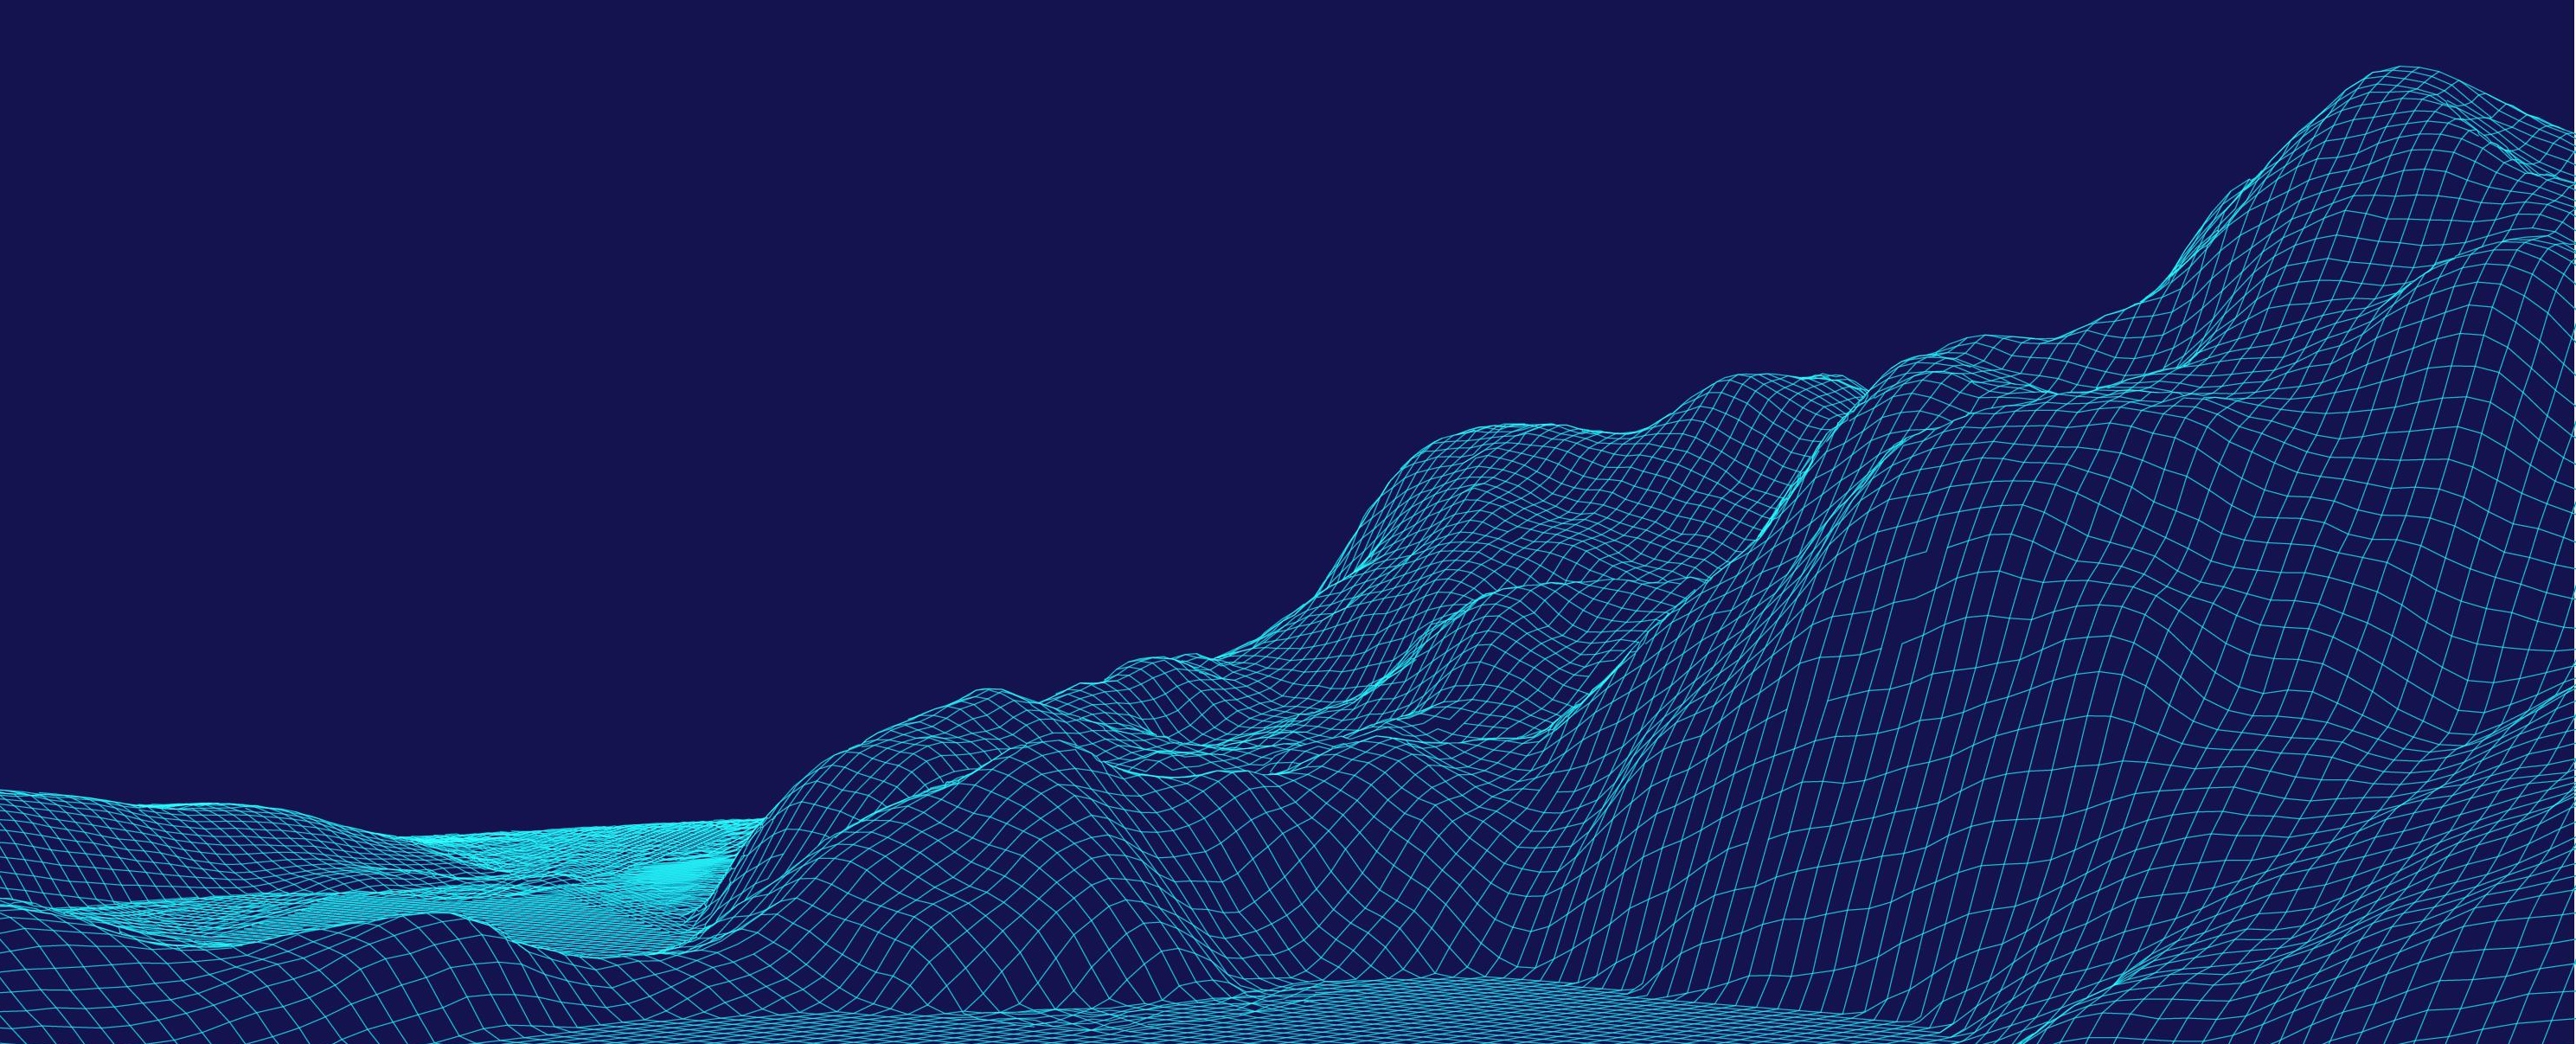

#### Requirements Installation

In [ ]:
%pip install pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow lightgbm transformers requests prophet



### 1. Introduction to Time Series Analysis

Time series analysis involves analyzing time-ordered data points to extract meaningful statistics and identify characteristics such as trends, seasonality, and cyclic patterns. It is widely used in various fields such as finance, economics, weather forecasting, and more.

#### Key Concepts
- **Stationarity**: A time series is stationary if its statistical properties (mean, variance) do not change over time.
- **Seasonality**: Regular patterns or cycles in a time series that repeat over a specific period.

### 2. Fetching Weather Data

We will use the OpenWeatherMap API to fetch weather data for the last few months.

#### Fetching Data


To find the API key for the OpenWeatherMap API, you need to follow these steps:

1. **Sign Up or Log In**: Go to the [OpenWeatherMap website](https://home.openweathermap.org/users/sign_up) and sign up for a free account if you don't already have one. If you already have an account, log in.

2. **Navigate to API Keys**: Once logged in, go to the "API keys" section in your account settings. You can find this by clicking on your profile icon in the top right corner and selecting "API keys" from the dropdown menu.

3. **Generate an API Key**: If you don't have an API key yet, you can generate one by clicking on the "Create Key" button. Give your key a name and click "Generate". Your new API key will be displayed.

4. **Copy the API Key**: Copy the generated API key.

5. **Replace 'your_api_key'**: Replace the placeholder `'your_api_key'` in your code with the actual API key you copied.



Make sure to keep your API key secure and do not share it publicly. If you are working in a shared environment, consider using environment variables to store your API key securely.

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

API_KEY = 'your_api_key'
#API_KEY = '7b486cc89f02fe732ecbfee7e0a63d10'
CITY = 'new york city'
URL = f'http://api.openweathermap.org/data/2.5/onecall/timemachine'

def fetch_weather_data(city, api_key, days=30):
    end_date = datetime.now()
    weather_data = []
    
    for day in range(days):
        date = end_date - timedelta(days=day)
        timestamp = int(date.timestamp())
        response = requests.get(URL, params={
            'lat': city['lat'],
            'lon': city['lon'],
            'dt': timestamp,
            'appid': api_key
        })
        data = response.json()
        weather_data.append(data)
    
    return weather_data

city_coords = {'lat': 40.7128, 'lon': -74.0060}  # Example: New York City
weather_data = fetch_weather_data(city_coords, API_KEY)

# Convert to DataFrame
weather_df = pd.DataFrame([{
    'date': datetime.fromtimestamp(hourly['dt']),
    'temperature': hourly['temp'],
    'humidity': hourly['humidity']
} for day in weather_data for hourly in day['hourly']])

weather_df.set_index('date', inplace=True)
weather_df.head()



### 3. Exploratory Data Analysis (EDA)

#### Plotting the Data


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
plt.plot(weather_df['temperature'], label='Temperature')
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()



### 4. Stationarity and Seasonality

#### Stationarity
A time series is stationary if its statistical properties do not change over time. We can use the Augmented Dickey-Fuller test to check for stationarity.



In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(weather_df['temperature'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])



#### Seasonality
Seasonality refers to periodic fluctuations. We can use seasonal decomposition to observe seasonality.



In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weather_df['temperature'], model='additive', period=24)
decomposition.plot()
plt.show()



### 5. Time Series Forecasting Algorithms

#### ARIMA
ARIMA (AutoRegressive Integrated Moving Average) is a popular time series forecasting method.

**Mathematical Background**:
$$
ARIMA(p, d, q):
$$

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \ldots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \ldots + \theta_q \epsilon_{t-q} + \epsilon_t
$$



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(weather_df['temperature'], order=(5, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=10)
print(forecast)

#### SARIMA
SARIMA (Seasonal ARIMA) extends ARIMA to support seasonality.

**Mathematical Background**:
$$
SARIMA(p, d, q)(P, D, Q)_s:
$$

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \ldots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \ldots + \theta_q \epsilon_{t-q} + \epsilon_t
$$

$$
+ \Phi_1 Y_{t-s} + \Phi_2 Y_{t-2s} + \ldots + \Phi_P Y_{t-Ps} + \Theta_1 E_{t-s} + \Theta_2 E_{t-2s} + \ldots + \Theta_Q E_{t-Qs}
$$

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(weather_df['temperature'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_fit = model.fit(disp=False)
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=10)
print(forecast)

#### SARIMAX
SARIMAX (Seasonal ARIMA with eXogenous variables) extends SARIMA to include exogenous variables.

**Mathematical Background**:
$$
SARIMAX(p, d, q)(P, D, Q)_s:
$$

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \ldots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \ldots + \theta_q \epsilon_{t-q} + \epsilon_t
$$

$$
+ \Phi_1 Y_{t-s} + \Phi_2 Y_{t-2s} + \ldots + \Phi_P Y_{t-Ps} + \Theta_1 E_{t-s} + \Theta_2 E_{t-2s} + \ldots + \Theta_Q E_{t-Qs} + \beta X_t
$$


In [ ]:
model = SARIMAX(weather_df['temperature'], exog=weather_df['humidity'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_fit = model.fit(disp=False)
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=10, exog=weather_df['humidity'][-10:])
print(forecast)

#### VARMA
VARMA (Vector AutoRegressive Moving Average) is used for multivariate time series.

**Mathematical Background**:
$$
VARMA(p, q):
$$

$$
Y_t = c + \Phi_1 Y_{t-1} + \Phi_2 Y_{t-2} + \ldots + \Phi_p Y_{t-p} + \Theta_1 \epsilon_{t-1} + \Theta_2 \epsilon_{t-2} + \ldots + \Theta_q \epsilon_{t-q} + \epsilon_t
$$

In [ ]:
from statsmodels.tsa.api import VARMAX

model = VARMAX(weather_df[['temperature', 'humidity']], order=(1, 1))
model_fit = model.fit(disp=False)
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=10)
print(forecast)

#### LSTM
LSTM (Long Short-Term Memory) networks are a type of recurrent neural network capable of learning long-term dependencies.

**Mathematical Background**:
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
\tilde{C_t} = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

$$
C_t = f_t * C_{t-1} + i_t * \tilde{C_t}
$$

$$
h_t = o_t * \tanh(C_t)
$$

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare data
data = weather_df['temperature'].values
data = data.reshape((len(data), 1))

# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Split into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Create sequences
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

seq_length = 24
X_train = create_sequences(train, seq_length)
y_train = train[seq_length:]
X_test = create_sequences(test, seq_length)
y_test = test[seq_length:]

# Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Forecast
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

#### RNN
Recurrent Neural Networks (RNN) are a type of neural network designed for sequential data.

**Mathematical Background**:
$$
h_t = \tanh(W_h \cdot [h_{t-1}, x_t] + b_h)
$$

$$
y_t = W_y \cdot h_t + b_y
$$

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Build RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Forecast
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

#### Holt-Winters
Holt-Winters method is used for forecasting time series data with seasonality.

**Mathematical Background**:
$$
\text{Level: } l_t = \alpha (y_t - s_{t-L}) + (1 - \alpha)(l_{t-1} + b_{t-1})
$$

$$
\text{Trend: } b_t = \beta (l_t - l_{t-1}) + (1 - \beta)b_{t-1}
$$

$$
\text{Seasonality: } s_t = \gamma (y_t - l_{t-1} - b_{t-1}) + (1 - \gamma)s_{t-L}
$$

$$
\text{Forecast: } \hat{y}_{t+h} = l_t + hb_t + s_{t-L+h}
$$

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(weather_df['temperature'], seasonal='add', seasonal_periods=24)
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=10)
print(forecast)

#### Prophet
Prophet is a forecasting tool developed by Facebook.

**Mathematical Background**:
$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$

$$
g(t) \text{ models the trend}
$$

$$
s(t) \text{ models the seasonality}
$$

$$
h(t) \text{ models the holidays}
$$

In [ ]:
from fbprophet import Prophet

# Prepare data
prophet_df = weather_df.reset_index().rename(columns={'date': 'ds', 'temperature': 'y'})

model = Prophet()
model.fit(prophet_df)

# Forecast
future = model.make_future_dataframe(periods=10, freq='H')
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

#### Transformers
Transformers are a type of model designed for handling sequential data.

**Mathematical Background**:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [ ]:
from transformers import TimeSeriesTransformer, TimeSeriesTransformerConfig

# Prepare data
data = weather_df['temperature'].values
data = data.reshape((len(data), 1))

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Split into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Create sequences
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

seq_length = 24
X_train = create_sequences(train, seq_length)
y_train = train[seq_length:]
X_test = create_sequences(test, seq_length)
y_test = test[seq_length:]

# Build Transformer model
config = TimeSeriesTransformerConfig()
model = TimeSeriesTransformer(config)

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Forecast
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)



### 6. Comparing Algorithms

#### Pros and Cons
- **ARIMA**:
  - Pros: Simple, interpretable.
  - Cons: Assumes linearity, not suitable for non-stationary data without differencing.
- **SARIMA**:
  - Pros: Handles seasonality.
  - Cons: Complex, requires parameter tuning.
- **SARIMAX**:
  - Pros: Handles seasonality and exogenous variables.
  - Cons: Complex, requires parameter tuning.
- **VARMA**:
  - Pros: Handles multivariate time series.
  - Cons: Complex, requires parameter tuning.
- **LSTM**:
  - Pros: Handles non-linearities, captures long-term dependencies.
  - Cons: Requires large datasets, computationally expensive.
- **RNN**:
  - Pros: Handles sequential data.
  - Cons: Prone to vanishing gradient problem, less effective than LSTM for long sequences.
- **Holt-Winters**:
  - Pros: Simple, handles seasonality.
  - Cons: Assumes linearity, not suitable for complex patterns.
- **Prophet**:
  - Pros: Handles seasonality, holidays, and missing data.
  - Cons: Less flexible than neural networks.
- **Transformers**:
  - Pros: Handles long sequences, captures complex patterns.
  - Cons: Computationally expensive, requires large datasets.
- **LGBM**:
  - Pros: Fast, handles large datasets, interpretable.
  - Cons: Requires feature engineering, may not capture temporal dependencies as well as LSTM.

### 7. Results Comparison



In [ ]:
import pandas as pd

# Assuming you have calculated MAE and RMSE for each model
results = {
    'Algorithm': ['ARIMA', 'SARIMA', 'SARIMAX', 'VARMA', 'LSTM', 'RNN', 'Holt-Winters', 'Prophet', 'Transformers', 'LGBM'],
    'MAE': [arima_mae, sarima_mae, sarimax_mae, varma_mae, lstm_mae, rnn_mae, hw_mae, prophet_mae, transformer_mae, lgbm_mae],
    'RMSE': [arima_rmse, sarima_rmse, sarimax_rmse, varma_rmse, lstm_rmse, rnn_rmse, hw_rmse, prophet_rmse, transformer_rmse, lgbm_rmse]
}

results_df = pd.DataFrame(results)
print(results_df)



### 8. Activity

#### Practice Activity
1. Fetch weather data for a different city.
2. Perform EDA on the new dataset.
3. Implement and compare the performance of ARIMA, SARIMA, SARIMAX, VARMA, LSTM, RNN, Holt-Winters, Prophet, Transformers, and LGBM on the new dataset.
4. Plot the results and compare the algorithms.

### Conclusion

This tutorial covered the basics of time series analysis, including stationarity and seasonality, and implemented various forecasting algorithms. We fetched weather data using the OpenWeatherMap API and compared the performance of different algorithms.